# 05 — LSTM (PyTorch)

**Goal:** a small, educational LSTM that predicts the **next-day log-return** from a window of recent returns, then reconstructs the price.

Steps: sequence preparation → model → training (early stopping) → prediction → evaluation.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
# make the models/ folder importable whether the notebook runs from models/ or the repo root
HERE = os.getcwd()
MODELS_DIR = HERE if os.path.exists(os.path.join(HERE, "utils.py")) else os.path.join(HERE, "models")
sys.path.insert(0, MODELS_DIR)
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
torch.manual_seed(utils.SEED); np.random.seed(utils.SEED)

## 1. Data and daily-return series

In [2]:
df = utils.load_modeling_frame()
train, val, test = utils.chrono_split(df)
i_train, i_val = len(train), len(train) + len(val)
log_y = np.log(df["y"].to_numpy())
r = np.diff(log_y, prepend=log_y[0])      # daily log-returns (r[0]=0)
target = df[utils.TARGET].to_numpy()       # next-day log-return per row

## 2. Scale (train only) and build sequences
Window length **L = 30** trading days. We standardize returns using **training** statistics only, to avoid leakage.

In [3]:
L = 30
mu, sd = r[:i_train].mean(), r[:i_train].std()
r_s = (r - mu) / sd

def make_seq(idxs):
    X, y, rows = [], [], []
    for t in idxs:
        if t < L:               # need L past returns
            continue
        X.append(r_s[t - L + 1:t + 1])
        y.append((target[t] - mu) / sd)   # scaled next-day return
        rows.append(t)
    return np.array(X)[:, :, None], np.array(y), np.array(rows)

Xtr, ytr, _ = make_seq(range(0, i_train))
Xva, yva, _ = make_seq(range(i_train, i_val))
Xte, yte, rows_te = make_seq(range(i_val, len(df)))
print("sequences:", Xtr.shape, Xva.shape, Xte.shape)

sequences: (1661, 30, 1) (363, 30, 1) (363, 30, 1)


## 3. Define the LSTM
One LSTM layer (hidden = 32) + a linear output.

In [4]:
class LSTMReg(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

model = LSTMReg()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossf = nn.MSELoss()
to_t = lambda a: torch.tensor(a, dtype=torch.float32)
Xtr_t, ytr_t = to_t(Xtr), to_t(ytr)
Xva_t, yva_t = to_t(Xva), to_t(yva)
Xte_t = to_t(Xte)

## 4. Train with early stopping (on validation loss)

In [5]:
best_val, best_state, patience, wait = float("inf"), None, 10, 0
val_hist = []
for epoch in range(150):
    model.train(); opt.zero_grad()
    loss = lossf(model(Xtr_t), ytr_t); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        vloss = lossf(model(Xva_t), yva_t).item()
    val_hist.append(vloss)
    if vloss < best_val - 1e-6:
        best_val = vloss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            break
model.load_state_dict(best_state)
print(f"stopped at epoch {epoch}; best val MSE {best_val:.5f}")

stopped at epoch 18; best val MSE 1.08515


## 5. Predict, reconstruct price, evaluate

In [6]:
model.eval()
with torch.no_grad():
    pred_s = model(Xte_t).numpy()
ret_pred = pred_s * sd + mu                       # inverse-scale -> log-return
price_pred = utils.reconstruct_price(test["y"].to_numpy(), ret_pred)
actual = utils.actual_test_price(test)
m = utils.evaluate(actual, price_pred)
print("LSTM:", {k: round(v, 4) for k, v in m.items()})
print("skill vs RW:", round(utils.skill_vs_rw(test, price_pred), 4),
      "| directional:", round(utils.directional_accuracy(test, price_pred), 3))
utils.save_predictions("lstm", test, price_pred);

LSTM: {'MAE': 1.3498, 'RMSE': 2.1047, 'MAPE': 1.0426, 'R2': 0.9923}
skill vs RW: 0.0027 | directional: 0.576


## 6. Plots

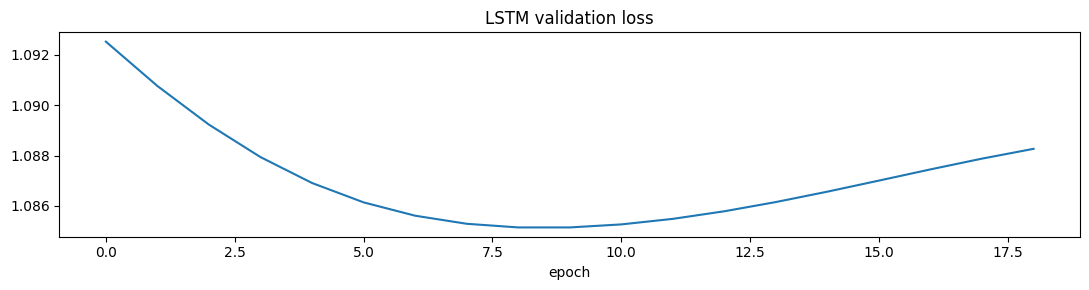

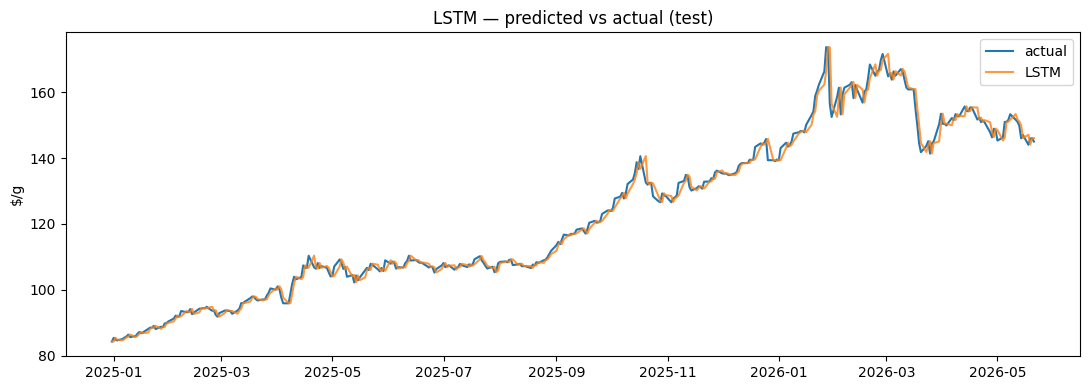

In [7]:
plt.figure(figsize=(11, 3)); plt.plot(val_hist)
plt.title("LSTM validation loss"); plt.xlabel("epoch"); plt.tight_layout(); plt.show()
plt.figure(figsize=(11, 4))
plt.plot(test["date"], actual, label="actual")
plt.plot(test["date"], price_pred, label="LSTM", alpha=.8)
plt.title("LSTM — predicted vs actual (test)"); plt.ylabel("$/g")
plt.legend(); plt.tight_layout(); plt.show()

## Conclusion
This univariate LSTM learns from past returns only. Because daily returns are close to noise, it tends toward a near-constant (random-walk-like) forecast — a useful lesson. A **multivariate** LSTM (feeding all 24 features per step) is the natural extension.